# Thematic Mapping in Python: Visualizing Crime Incidence in Mexico

Luis Edgar Vargas Ramirez

**Data sources:**
- [SESNSP Criminal Incidence Statistics](https://www.gob.mx/sesnsp/acciones-y-programas/datos-abiertos-de-incidencia-delictiva) (October 2025 release)
- [INEGI National Geostatistical Framework, State Level](https://www.inegi.org.mx/temas/mg/)

---

## Overview

This notebook demonstrates an end to end geospatial data workflow:

1. **Data loading**: reading tabular crime data and a vector shapefile of Mexico's 32 states
2. **Data cleaning & transformation**: filtering, aggregating, and joining datasets
3. **Thematic mapping**: producing publication-quality choropleth maps using both continuous and classified scales
4. **Visual refinement**: applying custom color palettes, typography, and layout to maximize interpretability

The variable of interest is **intentional homicide (homicidio doloso)** counts by state for the year 2024.


## 1. Environment Setup

Libraries used:
- `pandas` — tabular data manipulation
- `geopandas` — geospatial data handling (extends pandas to work with geometries)
- `matplotlib` — core plotting engine
- `seaborn` — statistical visualization
- `mapclassify` — classification schemes for choropleth maps (Quantiles, Jenks, etc.)
- `statsmodels` — used for exploratory statistical summaries

In [1]:
# Core libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
import statsmodels.api as sm

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)


## 2. Loading the Data

### 2.1 Shapefile; Mexico States

We load the official INEGI National Geostatistical Framework shapefile at the state (*entidad federativa*) level. This file contains the polygon geometries for Mexico's 32 states.

Key columns:
- `CVE_ENT` — numeric state code (FIPS-equivalent)
- `NOMGEO` — official state name
- `geometry` — polygon geometry in the original CRS

In [3]:
# Load the shapefile from the local data folder
shapefile_path = "C:/Users/REDGA/Desktop/Mexico_estados/00ent.shp"
map_mx = gpd.read_file(shapefile_path)

print(f"Shapefile loaded: {len(map_mx)} states")
print(f"Coordinate Reference System (CRS): {map_mx.crs}")
print(f"\nColumns: {list(map_mx.columns)}")
map_mx[['CVE_ENT', 'NOMGEO', 'geometry']].head(5)

Shapefile loaded: 32 states
Coordinate Reference System (CRS): PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Columns: ['CVEGEO', 'CVE_ENT', 'NOMGEO', 'geometry']


,CVE_ENT,NOMGEO,geometry
0,01,Aguascalientes,"POLYGON ((2469550.852 1159302.643, 2469738.209..."
1,02,Baja California,"MULTIPOLYGON (((1313480.513 1831458.607, 13135..."
2,03,Baja California Sur,"MULTIPOLYGON (((1694656.345 1227647.637, 16946..."
3,04,Campeche,"MULTIPOLYGON (((3544897.199 946994.621, 354491..."
4,05,Coahuila de Zaragoza,"POLYGON ((2469501.165 1978862.429, 2469539.651..."


### 2.2 Crime Incidence Data; SESNSP

The SESNSP (National Public Security Secretariat) publishes monthly crime incidence counts by state, broken down by crime type and subtype. The dataset uses Windows-1252 encoding, common in official Mexican government files.

In [5]:
# Load crime incidence data
# encoding='cp1252' is required for this official government file
crime_data = pd.read_csv("C:/Users/REDGA/Downloads/IDFC_oct2025.csv", encoding='cp1252')

print(f"Dataset shape: {crime_data.shape[0]:,} rows x {crime_data.shape[1]} columns")
print(f"\nCrime subtypes available: {crime_data['Subtipo de delito'].nunique()}")
print(f"Year range: {crime_data['Año'].min()} - {crime_data['Año'].max()}")
crime_data.head(5)

Dataset shape: 34,496 rows x 19 columns

Crime subtypes available: 55
Year range: 2015 - 2025


,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,3,0,2,1,1,1,2,1,2,2,2.00,1.00
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,1,0,0,0,1,0,1,0,0,0.00,1.00
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,0,2,2,3,2,0,1,2,0,0.00,0.00
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,2,0,0,1,0,0,0,0,0,0,0.00,0.00
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,0,0,0,1,0,0,0,0,0,0.00,0.00


## 3. Data Cleaning & Transformation

### 3.1 Compute Annual Totals

The dataset stores monthly counts in separate columns (January through December). We sum across all months to get an annual total per record.

In [6]:
# Define the month columns
months = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
          'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Sum across all months to get annual total
crime_data['Total'] = crime_data[months].sum(axis=1)

print("Annual total column created.")
print(f"Total crimes recorded across all years: {crime_data['Total'].sum():,}")

Annual total column created.
Total crimes recorded across all years: 21,422,235.0


### 3.2 Filter: Intentional Homicide Only

We focus on *homicidio doloso* (intentional homicide) — one of the most tracked crime categories in Mexico and internationally comparable.

In [7]:
# Filter to intentional homicide only
homicide = crime_data[crime_data['Subtipo de delito'] == 'Homicidio doloso'].copy()

print(f"Rows after filtering: {len(homicide):,}")
print(f"States covered: {homicide['Entidad'].nunique()}")
homicide[['Año', 'Entidad', 'Total']].head(5)

Rows after filtering: 1,408
States covered: 32


,Año,Entidad,Total
0,2015,Aguascalientes,18.00
1,2015,Aguascalientes,5.00
2,2015,Aguascalientes,12.00
3,2015,Aguascalientes,3.00
98,2015,Baja California,497.00


### 3.3 Aggregate by State and Year

Each state may have multiple rows (one per municipality or crime category breakdown). We aggregate to get a single total per state per year.

In [8]:
# Aggregate: sum homicides by year and state
homicide_by_state = (
    homicide
    .groupby(['Año', 'Clave_Ent', 'Entidad'])['Total']
    .sum()
    .reset_index()
)

# Filter to 2024 only
homicide_2024 = homicide_by_state[homicide_by_state['Año'] == 2024].copy()

print(f"States with 2024 data: {len(homicide_2024)}")
print(f"\nTop 5 states by homicide count (2024):")
homicide_2024.sort_values('Total', ascending=False).head(5)[['Entidad', 'Total']]

States with 2024 data: 32

Top 5 states by homicide count (2024):


,Entidad,Total
298,Guanajuato,"2,553.00"
289,Baja California,"2,089.00"
302,México,"1,964.00"
295,Chihuahua,"1,702.00"
306,Nuevo León,"1,539.00"


## 4. Joining Tabular Data to the Shapefile

This is the core ETL step in any geospatial workflow: merging statistical data onto geographic boundaries using a shared key.

Here we join on the state name (`NOMGEO` ↔ `Entidad`). A left join on the shapefile ensures all 32 states appear in the final map, even if some have missing data.

In [9]:
# Verify data types before joining — both keys must be the same type
print("Shapefile key dtype:", map_mx['NOMGEO'].dtype)
print("Crime data key dtype:", homicide_2024['Entidad'].dtype)

Shapefile key dtype: object
Crime data key dtype: object


In [10]:
# Merge: join crime data onto shapefile using state name as key
map_joined = map_mx.merge(
    homicide_2024[['Entidad', 'Total']],
    left_on='NOMGEO',
    right_on='Entidad',
    how='left'
)

# Check for unmatched states (nulls in Total after join)
unmatched = map_joined[map_joined['Total'].isna()]
if len(unmatched) > 0:
    print(f"Warning: {len(unmatched)} states did not match:")
    print(unmatched['NOMGEO'].values)
else:
    print(f"All {len(map_joined)} states matched successfully.")

map_joined[['NOMGEO', 'Total']].sort_values('Total', ascending=False).head(5)

All 32 states matched successfully.


,NOMGEO,Total
10,Guanajuato,"2,553.00"
1,Baja California,"2,089.00"
14,México,"1,964.00"
7,Chihuahua,"1,702.00"
18,Nuevo León,"1,539.00"


## 5. Thematic Mapping

Two choropleth maps of the same variable were produced, using different classification approaches:

- **Map 1 — Continuous scale:** Shows the raw gradient of values. Useful for identifying extreme outliers.
- **Map 2 — Quantile classification (5 bins):** Divides states into 5 equal-frequency groups. More robust to outliers and easier to interpret comparatively.

### 5.1 Map 1: Continuous Color Scale

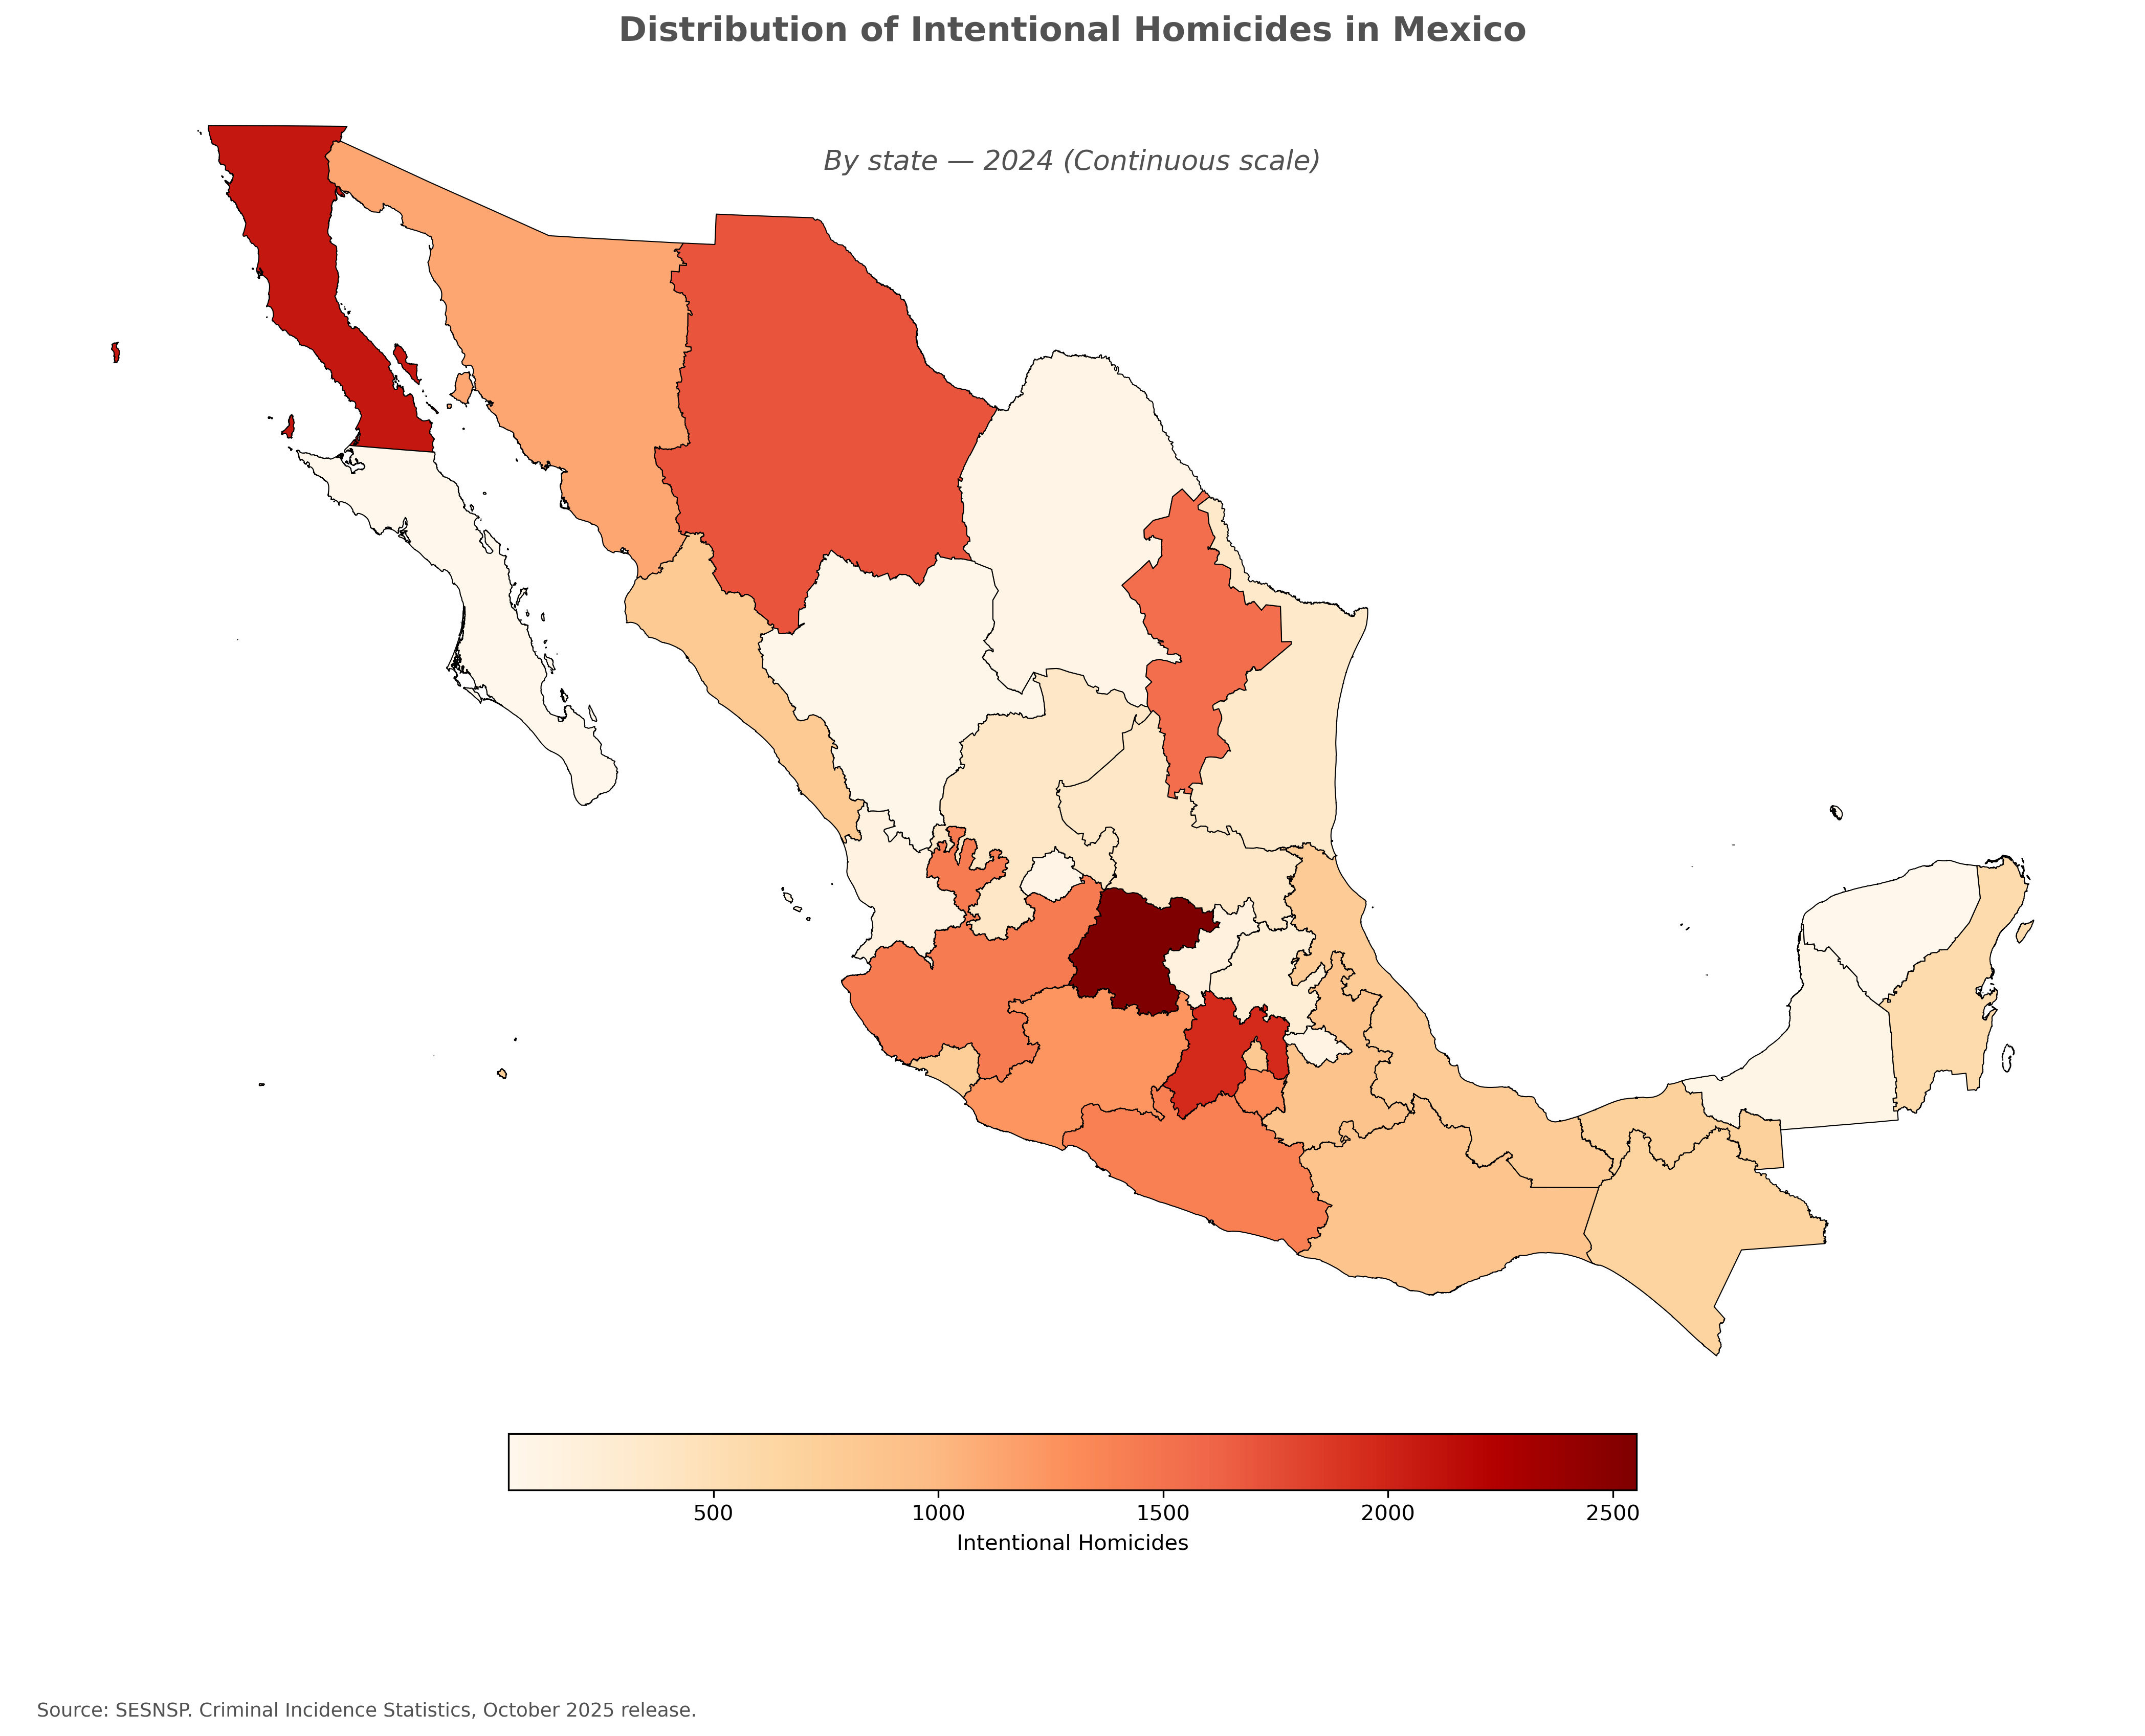

Map 1 saved.


In [13]:
fig, ax = plt.subplots(figsize=(15, 12), dpi=300)

map_joined.plot(
    column='Total',
    ax=ax,
    legend=True,
    cmap='OrRd',
    legend_kwds={
        'label': 'Intentional Homicides',
        'orientation': 'horizontal',
        'shrink': 0.5,
        'pad': 0.01
    },
    edgecolor='black',
    linewidth=0.5
)

ax.set_axis_off()

# Title and annotations
plt.figtext(0.5, 0.95, 'Distribution of Intentional Homicides in Mexico',
            fontweight='bold', color='#525252', ha='center', fontsize=16)
plt.figtext(0.5, 0.88, 'By state — 2024 (Continuous scale)',
            style='italic', color='#525252', ha='center', fontsize=13)
plt.figtext(0.05, 0.04, 'Source: SESNSP. Criminal Incidence Statistics, October 2025 release.',
            color='#525252', fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('map1_continuous.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Map 1 saved.")

**Reading the map:** The continuous scale makes it easy to spot that a small number of states (particularly in the northwest and center-west) account for a disproportionate share of homicides. However, the skewed distribution compresses most states into the lighter end of the scale, which is where quantile classification helps.

### 5.2 Map 2: Quantile Classification with Custom Palette

A quantile scheme assigns equal numbers of states to each color bin. This removes the distortion caused by outliers and makes regional patterns more visible.

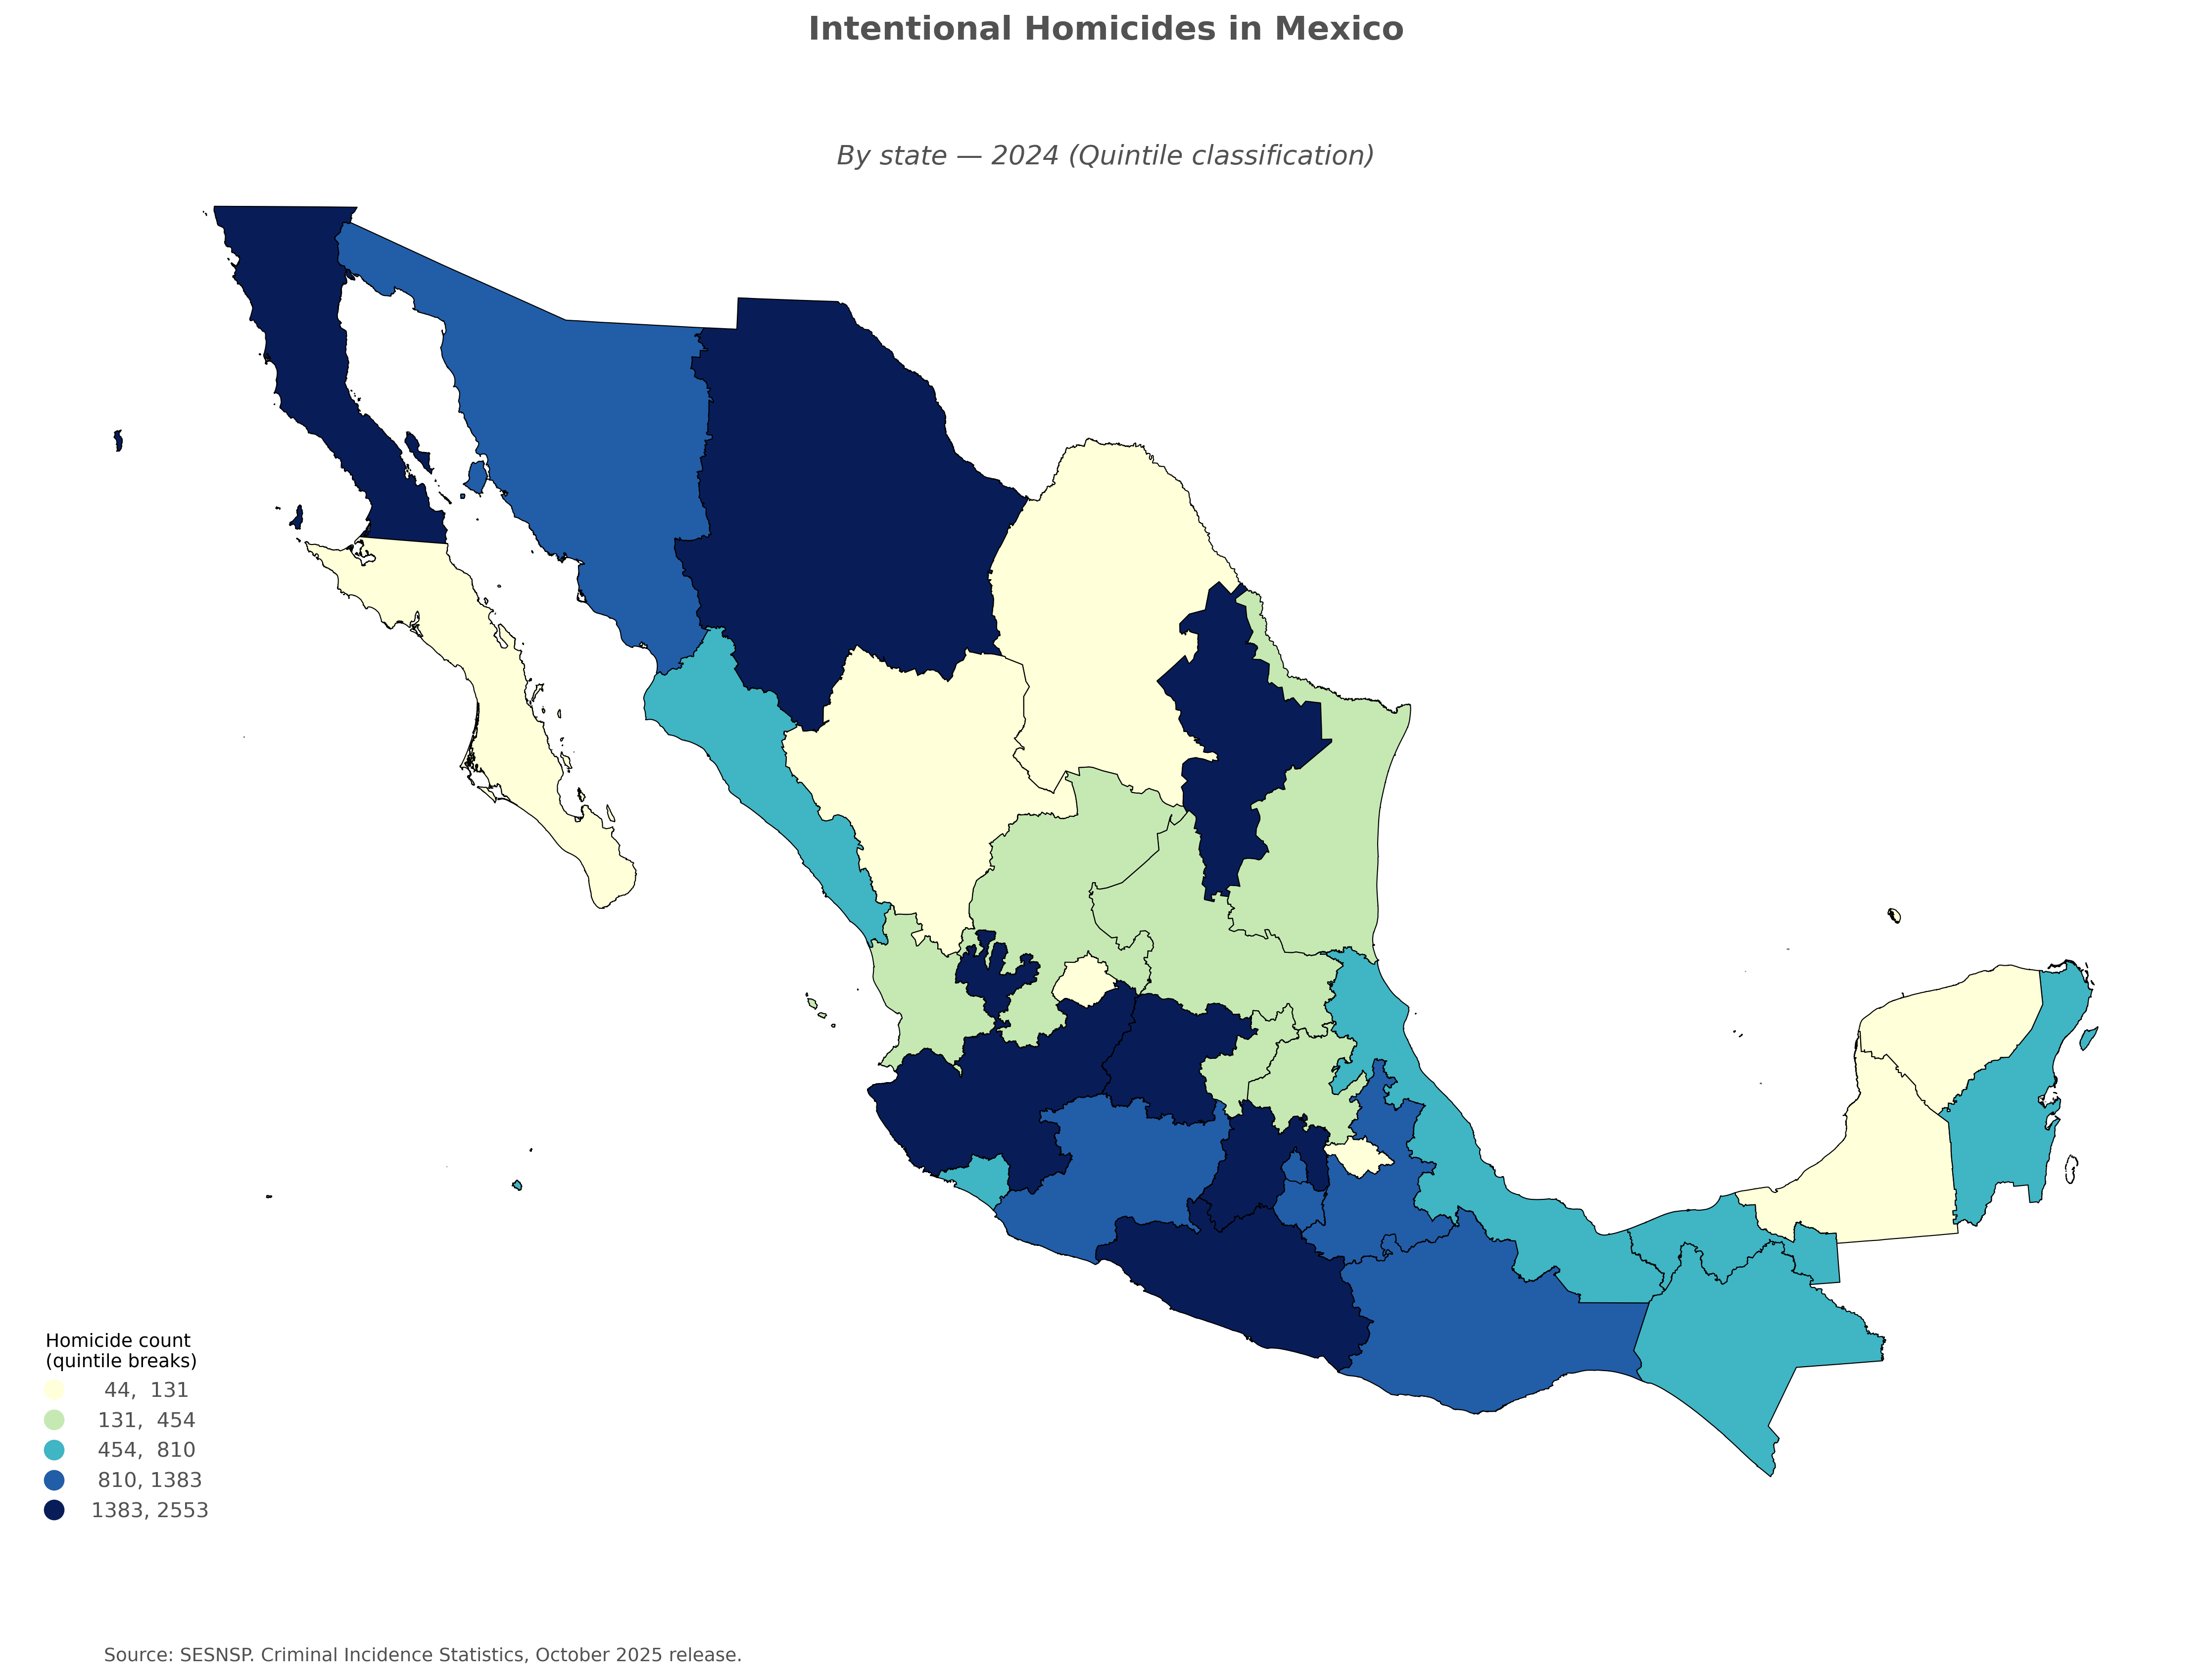

In [23]:
cmap_custom = ListedColormap(custom_palette)

fig, ax = plt.subplots(figsize=(15, 12), dpi=300)

map_joined.plot(
    column='Total',
    ax=ax,
    scheme='Quantiles',   # Equal-frequency classification
    k=5,                  # 5 bins (quintiles)
    legend=True,
    cmap='YlGnBu',
    legend_kwds={
        'loc': 'lower left',
        'fmt': '{:.0f}'   # Show integer values in legend
    },
    edgecolor='black',
    linewidth=0.5
)

ax.set_axis_off()

# Style the legend text
leg = ax.get_legend()
if leg:
    for text in leg.get_texts():
        text.set_color('#525252')
    leg.get_frame().set_linewidth(0)
    leg.get_frame().set_edgecolor('none')
    leg.set_title('Homicide count\n(quintile breaks)', prop={'size': 9})

# Title and annotations
plt.figtext(0.5, 0.95, 'Intentional Homicides in Mexico',
            fontweight='bold', color='#525252', ha='center', fontsize=16)
plt.figtext(0.5, 0.88, 'By state — 2024 (Quintile classification)',
            style='italic', color='#525252', ha='center', fontsize=13)
plt.figtext(0.05, 0.04, 'Source: SESNSP. Criminal Incidence Statistics, October 2025 release.',
            color='#525252', fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('map2_quantile.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

**Reading the map:** The quintile map reveals a clearer north-south regional pattern. States in the northwest (Baja California, Sonora, Chihuahua) and centerwest (Guanajuato, Michoacán) fall in the darkest quintile, while southern and southeastern states generally show lower counts. The classification makes it easier to communicate relative standing across states.

## 6. Summary Statistics

In [24]:
# Summary of homicide distribution across states
summary = map_joined['Total'].describe().rename({
    'count': 'States',
    'mean': 'Mean',
    'std': 'Std Dev',
    'min': 'Min',
    '25%': 'Q1 (25th pct)',
    '50%': 'Median',
    '75%': 'Q3 (75th pct)',
    'max': 'Max'
})


print("Intentional Homicides by State — 2024")
print("=" * 40)
print(summary.to_string())
print(f"\nNational total: {int(map_joined['Total'].sum()):,}")

# Top and bottom 5
print("\nTop 5 states:")
print(map_joined[['NOMGEO', 'Total']]
      .sort_values('Total', ascending=False)
      .head(5)
      .to_string(index=False))

print("\nBottom 5 states:")
print(map_joined[['NOMGEO', 'Total']]
      .sort_values('Total')
      .head(5)
      .to_string(index=False))

Intentional Homicides by State — 2024
States             32.00
Mean              795.72
Std Dev           676.37
Min                44.00
Q1 (25th pct)     166.50
Median            728.00
Q3 (75th pct)   1,265.25
Max             2,553.00

National total: 25,463

Top 5 states:
         NOMGEO    Total
     Guanajuato 2,553.00
Baja California 2,089.00
         México 1,964.00
      Chihuahua 1,702.00
     Nuevo León 1,539.00

Bottom 5 states:
              NOMGEO  Total
             Yucatán  44.00
 Baja California Sur  56.00
             Durango  64.00
            Campeche  95.00
Coahuila de Zaragoza 105.00


## 7. Conclusions

This notebook demonstrated a simple and complete geospatial ETL and visualization workflow:

**Pipeline steps completed:**
1. Loaded a government shapefile (INEGI) and a large tabular crime dataset (SESNSP)
2. Cleaned and filtered the data to isolate intentional homicide for 2024
3. Aggregated monthly counts to annual state-level totals
4. Joined the statistical data to geographic boundaries using the state name as a key
5. Produced two choropleth maps using different classification schemes

**Key findings:**
- Intentional homicide is geographically concentrated: the top quintile of states accounts for a disproportionate share of the national total
- The continuous scale highlights outliers; the quantile scale reveals regional clustering patterns
- The northwest and center-west regions show consistently elevated counts

**Methodological note on classification:**  
The choice of classification scheme (continuous vs. quantile vs. Jenks natural breaks) significantly affects how a map is interpreted. For redistricting and demographic analysis, quantile or equal-interval schemes are most common as they communicate relative standing across units clearly.

---
*This analysis was conducted using open government data. All code is reproducible using the data files included in the `data/` folder.*